In [2]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display
from scipy.optimize import curve_fit
from scipy.stats import norm
from functools import reduce

import gc
import itertools

In [3]:
#base_path = "../../mnt/SingleTrackTrees/Simulation/alice_sim_2024_LHC24h1_1_536237_AOD"
base_path = "/home/pira/Documenti/PoD/LCP/LCP_B/ALICE"
which_chunk = ["001_010", "011_020", "021_030", "031_040", "041_050", "051_060", "061_070", "071_080", "081_090", "091_100" ]
which_file = "AO2DtreeMC.root"

In [4]:
def to_global_coord( row ):
    xy_in = np.array([row["fX"],row["fY"]])
    # angle = -row["fAlpha"]
    # rot = np.array([[np.cos(angle),np.sin(angle)], [-np.sin(angle), np.cos(angle)]]) # inverse matrix of the one from to_track_coord (-alfa)
    # Rewriting the above matrix using cosine/sin even/odd function properties: less multiplications
    angle = row["fAlpha"]
    rot = np.array([[np.cos(angle),-np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    xy_out = rot.dot(xy_in)
    return( xy_out )

def secondary_vertex ( row1, row2 ):
    XY1, XY2 = [to_global_coord(row1), to_global_coord(row2)]
    x1 = XY1[0]
    y1 = XY1[1]
    x2 = XY2[0]
    y2 = XY2[1]
    
    px1 = row1["px"]
    px2 = row2["px"]
    py1 = row1["py"]
    py2 = row2["py"]
    pz1 = row1["pz"]
    pz2 = row2["pz"]
    
    m1 = py1/px1
    m2 = py2/px2
    q1 = y1 - m1*x1
    q2 = y2 - m2*x2
    x_SV = ( q2 - q1 )/( m1 - m2)
    y_SV = y1 + m1*(x_SV - x1)

    # NEW: Benedetto's fix
    z1_track = pz1/px1 * (x_SV - x1) + row1["fZ"]
    z2_track = pz2/px2 * (x_SV - x2) + row2["fZ"]
    z_SV = (z1_track + z2_track)/2
    return ([x_SV, y_SV, z_SV])

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

# Pt intervals and labels
Pt_intervals = [0, 1, 2, 3, 5, 8, 41]
Pt_labels = ["0-1", "1-2", "2-3", "3-5", "5-8", "8-41"]

# parameters
acceptance = 0.8

$$
\begin{align}
D^0 \rightarrow K^- \quad \pi^+ \\
421 \rightarrow -321 \quad211
\end{align}
$$


$$
\begin{align}
\overline{D^0} \rightarrow& \quad K^+ \qquad \pi^- \\
-421 \rightarrow& +321 \quad-211
\end{align}
$$

In [5]:
# NSigmaTPC:
#sigma_limit = 3
#cut1 = (
    "( (fNsigmaTPCpi > -3) & (fNsigmaTPCpi < 3) & (fCharge == 1) ) | "
    "( (fNsigmaTPCka > -3) & (fNsigmaTPCka < 3) & (fCharge == -1) ) | "
    "( (fPt > 0) & (fPt < 1) & (fNsigmaTPCka > -15) & (fNsigmaTPCka < 0) & (fCharge == 1) )"
#)

# NsigmaTOF:
sigma_limit = 3
cut2 = (
    "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
    "( (fNsigmaTOFka > -3) & (fNsigmaTOFka < 3) & (fCharge == -1) ) | "
  # "( (fNsigmaTOFka > 998.5) | (fNsigmaTOFka < -998.5) | (fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "
  # "( (fPt > 0) & (fPt < 3) & (fNsigmaTOFka > -50) & (fNsigmaTOFka < 0) & (fCharge == 1) )"
)

# DCA_XY:
#cut3 = "( (fDcaXY > 0.0002) | (fDcaXY < -0.0002) )"


# FINAL CUT EXPRESSION:
#cut_expression = f"({cut1}) & ({cut2}) & ({cut3})"
cut_expression = f"({cut2})"

In [6]:
collision_offset = 0          # variable to correct the index of the collision (because it starts from 0 at each new TTree)
filtered_dfs = []

for chunk in which_chunck:
    path = base_path + "/".join(["/",chunck , which_file])
    file = uproot.open(path)

    names_track_extr = file.keys(filter_name=r"*O2filtertrackextr")
    names_track      = file.keys(filter_name=r"*O2filtertrack")
    names_coll       = file.keys(filter_name=r"*O2collision_001")
    
    names_mc_gen     = file.keys(filter_name=r"*O2genparticles")
    names_mc_track   = file.keys(filter_name=r"*O2filtertrackmc")
    names_mc_coll    = file.keys(filter_name=r"*O2mccollision")

    list_of_df = []               # add the dataframes in a list (we will concat them later)

    for i in range (len(names_coll)):
        # Read collision tree
        df_coll = file[ names_coll[i] ].arrays(["fPosX", "fPosY", "fPosZ"], library="pd")   # I take the fPosZ column as a DataFrame
    
        # # Read track and trackextr using boolean mask for track and trackextr:
        df_trackextr = file[ names_track_extr[i] ].arrays(["fPt", "fEta", "fCharge", "fDcaXY",
             "fNsigmaTPCpi", "fNsigmaTPCka", "fNsigmaTPCpr", "fNsigmaTOFpi", "fNsigmaTOFka"], library="pd" )
        df_track = file[ names_track[i] ].arrays(["fIndexCollisions", "fAlpha", "fX", "fY", "fZ"], library="pd")
    
        # take the corresponding data of MC
        df_track_mc = file[names_mc_track[i]].arrays(["fPdgCode","fMainMotherOrigIndex","fMainHfMotherPdgCode","fMainMotherNfinalStateDaught",
                                                      "fMainBeautyAncestorPdgCode"],library="pd")
        df_track = pd.merge(left=df_track, 
                             right=df_track_mc, 
                             how='inner', left_index=True, right_index=True)
    
        # merge all rows
        df_trackextr = pd.merge(left=df_trackextr, right=df_track, how='inner', left_index=True, right_index=True)
    
        # keep all particles that come from D0 AND are either K- or pi+ AND fMainBeautyAncestor = 0
        # For D0
        #is_D0 = (df_trackextr["fMainHfMotherPdgCode"]  == +421) & (df_trackextr["fPdgCode"].isin([-321,+211]) ) & \
        #(df_trackextr["fMainBeautyAncestorPdgCode"]==0)
        
        #is_anti_D0 = (df_trackextr["fMainHfMotherPdgCode"]  == -421) & (df_trackextr["fPdgCode"].isin([+321,-211]) ) & \
        #(df_trackextr["fMainBeautyAncestorPdgCode"]==0)
        #df_trackextr = df_trackextr[is_D0 | is_anti_D0]
    
        # keep only those with 2 or more daughter
        #df_trackextr = df_trackextr[df_trackextr["fMainMotherNfinalStateDaught"] >= 2]
    
         mask = df_trackextr.eval(cut_expression)        # create boolean mask
        # # Apply the SAME filter to df_trackextr and df_track to keep them aligned (and keep only useful columns):
         df_trackextr = df_trackextr.loc[mask].reset_index(drop=True)

        # NEW: We keep the variables over which we did the cut to see how they behave for the signal
        df_trackextr = df_trackextr[["fIndexCollisions","fMainMotherOrigIndex","fAlpha", "fX", "fY", "fZ","fPt", "fEta", "fCharge", "fDcaXY","fMainHfMotherPdgCode",
                                     "fPdgCode","fNsigmaTPCpi", "fNsigmaTPCka","fNsigmaTOFpi", "fNsigmaTOFka", "fMainBeautyAncestorPdgCode", "fMainMotherNfinalStateDaught"]]
    
        # we cut rows where the fIndexCollision is negative (for some reason)
        valid = df_trackextr["fIndexCollisions"] >= 0
        df_trackextr = df_trackextr[valid].reset_index(drop=True)  
    
        
        # Now we for correct fPosZ (and add that column)
        df_trackextr["fPosZ"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosZ"].values
      
        df_trackextr["fPosX"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosX"].values
    
        df_trackextr["fPosY"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosY"].values
        
        # cut |posZ|<10
        df_trackextr = df_trackextr[(df_trackextr["fPosZ"] < 10) & (df_trackextr["fPosZ"] > -10)].reset_index(drop=True)
        # select eta < 0.8
        df_trackextr = df_trackextr[df_trackextr["fEta"] < acceptance].reset_index(drop=True)

        
        df_trackextr["fIndexCollisions"] += collision_offset   # Fix local fIndexCollisions → global index
        df_trackextr["fMainMotherOrigIndex"] += collision_offset
        
        # save results:
        # ALTERNATIVE 1: for the first cycle, let's copy the first dataframe, then we concatenate the next ones
        # if  i==0: df = df_trackextr
        # else: df = pd.concat([df, df_trackextr], ignore_index=True)
        # # ALTERNATIVE 2:
        list_of_df.append( df_trackextr )                  # add the dataframe in a list (we will concat them later)
        
        # Update offset for next loop
        collision_offset += len(df_coll)

    # Merge everything in the total dataframe
    df = pd.concat(list_of_df, ignore_index=True)
    
    N = len(df)
    
    # moment columns:
    df["px"] = df["fPt"] * np.cos(df["fAlpha"])
    df["py"] = df["fPt"] * np.sin(df["fAlpha"])
    df["pz"] = df["fPt"] * np.sinh(df["fEta"])
    
    # energy column (differentiating pions and kaons): # CHECK HERE THE MASS 
    mass = np.where(df["fCharge"] > 0, m_pi, m_K)
    anti_mass = np.where(df["fCharge"] > 0, m_K, m_pi)
    df["Ene"] = np.sqrt((df["fPt"] * np.cosh(df["fEta"]))**2 + mass**2)
    df["Anti_Ene"] = np.sqrt((df["fPt"] * np.cosh(df["fEta"]))**2 + anti_mass**2)
    
    # Debug
    print(f"The dataframe before pair computation of chunk {chunk} has", len(df), "rows and ", len(df.columns), "columns.")
    memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"It occupies {memory:.2f} MB")

    # let's initialize some lists, then we will create a dataframe
    collision_indices = []
    track1_indices = []
    track2_indices = []
    dcaXY_products = []
    inv_masses = []
    anti_masses = []
    inv_masses_approx = []
    pt_totals = []
    pz_totals = []
    SV_X = []
    SV_Y = []
    SV_Z = []
    decay_lengths = []
    cos_pointings = []
    #mother_type = []

    # filter variables behaviour
    KA_TPCka = []
    KA_TOFka = []
    PI_TPCpi = []
    PI_TOFpi = []

    # also cross-check over the other particles's variables (e.g. the TOFpi for a ka particle)
    KA_TPCpi = []
    KA_TOFpi = []
    PI_TPCka = []
    PI_TOFka = []

    # also for the fDCAXY of the two daughters
    KA_fDcaXY = []
    PI_fDcaXY = []

    # and their transverse momentum
    KA_pt = []
    PI_pt = []

    # MC informations
    positive_pdg = []
    negative_pdg = []
    mother_pdg_pos = []
    mother_pdg_neg = []
    beauty_ancestor_pos = []
    beauty_ancestor_neg = []
    mother_N_final_state_pos = []
    mother_N_final_state_neg = []
    mother_orig_ind_pos = []
    mother_orig_ind_neg = []

    
    
    counting=0 # debug variable
    
    # let's divide the dataframe for positive and negative charged
    df_pos = df[ df['fCharge']>0 ]
    df_neg = df[ df['fCharge']<0 ]
    
    # Iterate over each collision group
    for collision_idx in (df_neg['fIndexCollisions'].unique()):
        group_pos = df_pos[ df_pos['fIndexCollisions'] == collision_idx ]
        group_neg = df_neg[ df_neg['fIndexCollisions'] == collision_idx ]
    
        # Only collisions with at least a pair
        if len(group_pos) < 1:   continue
    
        # Reset index of the group to 0..N-1 and move original index in new column 'orig_index'
        group_pos = group_pos.reset_index().rename(columns={'index': 'orig_index'})
        group_neg = group_neg.reset_index().rename(columns={'index': 'orig_index'})
    
        # let's crate indexes for all possible pairs:
        combinat = itertools.product( range(len(group_neg)), range(len(group_pos)) )
    
        # Iterate over all unique pairs of tracks
        for combo in combinat:
            row_neg = group_neg.iloc[combo[0]]
            row_pos = group_pos.iloc[combo[1]]
    
            product_dcaXY = row_neg['fDcaXY'] * row_pos['fDcaXY']
            
            # INVARIANT MASS calculation
            pt1, pt2 = row_neg['fPt'], row_pos['fPt']
            # eta1, eta2 = row_neg['fEta'], row_pos['fEta']
            # phi1, phi2 = row_neg['fAlpha'], row_pos['fAlpha']
            # delta_eta = eta1 - eta2
            # delta_phi = phi1 - phi2
    
            # approximation formula
            # inv_mass_approx = np.sqrt(2 * pt1 * pt2 * (np.cosh(delta_eta) - np.cos(delta_phi)))
    
            # exact formula:
            E1 = row_neg['Ene']
            E2 = row_pos['Ene']
            px1 = row_neg["px"]
            py1 = row_neg["py"]
            pz1 = row_neg["pz"]
            px2 = row_pos["px"]
            py2 = row_pos["py"]
            pz2 = row_pos["pz"]
            inv_mass = np.sqrt( (E1+E2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2 )

            # Mass for anti-D0 (use mask on mother's PDG code for histograms)
            anti_E1 = row_neg['Anti_Ene']
            anti_E2 = row_pos['Anti_Ene']
            anti_inv_mass = np.sqrt( (anti_E1+anti_E2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2 )
    
            # total transverse momentum of the D0 candidate (used later for sliced plots)
            pt_total = np.sqrt((px1 + px2)**2 + (py1 + py2)**2)
    
            # secondary vertex
            SV_coords = np.array( secondary_vertex(row_neg, row_pos) )
            # SV_X.append(SV_coords[0])
            # SV_Y.append(SV_coords[1])
            # SV_Z.append(SV_coords[2])
    
            # decay length: distance between PV and SV
            PV_coords = np.array( [row_pos["fPosX"], row_pos["fPosY"], row_pos["fPosZ"]] )
            decay_lengths.append( np.linalg.norm(SV_coords - PV_coords ) )
    
            # cosine of pointing angle: the latter is the angle between the direction of the mother particle and the line connecting PV and SV
            mother_direction = [px1+px2, py1+py2, pz1+pz2]
            flight_line = SV_coords - PV_coords
            cos_pointings.append ( np.dot(mother_direction, flight_line)/(np.linalg.norm(mother_direction)*np.linalg.norm(flight_line)) )
            
            # let's add the found pairs to the lists
            collision_indices.append(int(row_neg['fIndexCollisions']))
            # track1_indices.append(int(row_neg['orig_index']))
            # track2_indices.append(int(row_pos['orig_index']))
            dcaXY_products.append(product_dcaXY)
            inv_masses.append(inv_mass)
            anti_masses.append(anti_inv_mass)
            #mother_type.append( np.where(row_pos["fMainHfMotherPdgCode"]==421, True, False)  )
            # inv_masses_approx.append(inv_mass_approx)
            pt_totals.append(pt_total)
            pz_totals.append(pz1+pz2)
            # variable check: for D0, kaon is minus---> Ka<-->row neg; pi<-->row pos
            
            KA_pt.append(row_neg['fPt'])
            KA_TPCka.append(row_neg["fNsigmaTPCka"])
            KA_TOFka.append(row_neg["fNsigmaTOFka"])
            KA_fDcaXY.append(row_neg["fDcaXY"])

            PI_pt.append(row_pos['fPt'])
            PI_TPCpi.append(row_pos["fNsigmaTPCpi"])
            PI_TOFpi.append(row_pos["fNsigmaTOFpi"])
            PI_fDcaXY.append(row_pos["fDcaXY"])
        
            # also cross-check over the other particles's variables (e.g. the TOFpi for a ka particle)
            KA_TPCpi.append(row_neg["fNsigmaTPCpi"])
            KA_TOFpi.append(row_neg["fNsigmaTOFpi"])
            PI_TPCka.append(row_pos["fNsigmaTPCka"])
            PI_TOFka.append(row_pos["fNsigmaTOFka"])

            #append the MC informations#------------------------------------------------------DONE
            positive_pdg.append(row_pos["fPdgCode"])
            negative_pdg.append(row_neg["fPdgCode"])
            mother_pdg_pos.append(row_pos["fMainHfMotherPdgCode"])
            mother_pdg_neg.append(row_neg["fMainHfMotherPdgCode"])
            beauty_ancestor_pos.append(row_pos["fMainBeautyAncestorPdgCode"])
            beauty_ancestor_neg.append(row_neg["fMainBeautyAncestorPdgCode"])
            mother_N_final_state_pos.append(row_pos["fMainMotherNfinalStateDaught"])
            mother_N_final_state_neg.append(row_neg["fMainMotherNfinalStateDaught"])
            mother_orig_ind_pos.append(row_pos["fMainMotherOrigIndex"])
            mother_orig_ind_neg.append(row_neg["fMainMotherOrigIndex"])

    
    
        # # let's free the memory RAM of unused dataframes:
        # # PROBLEM: THIS IS VERY SLOW!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
        # del group
        # gc.collect()
    
        # debug:
        counting += 1
        if counting % 50000 ==0: print(counting, end=' ')


    # create a dataframe with the result:
    df_pairs = pd.DataFrame({
        #'Is_This_D0': mother_type,
        'collision_index': collision_indices,
        'dcaXY_product': dcaXY_products,
        'inv_mass': inv_masses,
        'anti_mass': anti_masses,
        'pt': pt_totals,
        'pz': pz_totals,
        'decay_length': decay_lengths,
        'cos_pointing': cos_pointings,
        'KA_pt': KA_pt,
        'KA_TPCka': KA_TPCka,
        'KA_TOFka': KA_TOFka,
        'KA_fDcaXY': KA_fDcaXY,
        'PI_pt': PI_pt,
        'PI_TPCpi': PI_TPCpi,
        'PI_TOFpi': PI_TOFpi,
        'PI_fDcaXY': PI_fDcaXY,
        'KA_TPCpi': KA_TPCpi,
        'KA_TOFpi': KA_TOFpi,
        'PI_TPCka': PI_TPCka,
        'PI_TOFka': PI_TOFka,
        #... aggiungere le liste nuove
        'pdg_pos':positive_pdg,
        'pdg_neg':negative_pdg,
        'MC_mother_pdg_pos': mother_pdg_pos,
        'MC_mother_pdg_neg': mother_pdg_neg,
        'MC_beauty_ancestor_pos': beauty_ancestor_pos,
        'MC_beauty_ancestor_neg': beauty_ancestor_neg,
        'MC_mother_origin_pos': mother_orig_ind_pos,
        'MC_mother_origin_neg': mother_orig_ind_neg,
        'N_final_states_pos': mother_N_final_state_pos,
        'N_final_states_neg': mother_N_final_state_neg        
    })
    # Debug
    print(f"The final dataframe after filters and pair computation of chunk {chunk} has", len(df_pairs), "rows and ",
          len(df_pairs.columns), "columns.")
    memory = df_pairs.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"It occupies {memory:.2f} MB")
    display( pd.concat([df_pairs.head(3),df_pairs.tail(3)]) )

    filtered_dfs.append(df_pairs)

final_results = pd.concat(filtered_dfs,ignore_index=True)

The dataframe before pair computation of chunk 0 has 1601056 rows and  26 columns.
It occupies 171.01 MB
50000 100000 150000 The final dataframe after filters and pair computation of chunk 0 has 5619164 rows and  30 columns.
It occupies 1286.12 MB


,collision_index,dcaXY_product,inv_mass,anti_mass,pt,pz,decay_length,cos_pointing,KA_pt,KA_TPCka,...,pdg_pos,pdg_neg,MC_mother_pdg_pos,MC_mother_pdg_neg,MC_beauty_ancestor_pos,MC_beauty_ancestor_neg,MC_mother_origin_pos,MC_mother_origin_neg,N_final_states_pos,N_final_states_neg
0,0,0.000043,1.078002,0.965592,2.071664,-0.463106,0.008672,0.541366,0.818927,-1.574181,...,211.0,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0
1,0,-0.000023,0.954106,0.976759,1.351086,-0.387014,0.017328,0.987720,0.818927,-1.574181,...,211.0,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0
2,0,-0.000048,1.533463,1.549260,0.686016,0.175444,6.203392,-0.249098,0.818927,-1.574181,...,211.0,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0
5619161,219048,-0.000039,1.014976,0.971305,0.106706,-0.423170,0.008393,0.658117,0.322527,-10.529971,...,211.0,-211.0,0.0,0.0,0.0,0.0,218256.0,218256.0,0.0,0.0
5619162,219048,0.000098,0.918062,0.879526,0.372284,-0.426943,0.020407,-0.080143,0.322527,-10.529971,...,211.0,-211.0,0.0,0.0,0.0,0.0,218256.0,218256.0,0.0,0.0
5619163,219050,0.000015,0.727760,0.709166,1.454188,1.238617,0.113689,0.999210,0.702691,-1.427458,...,211.0,-211.0,0.0,0.0,0.0,0.0,218256.0,218256.0,0.0,0.0


In [7]:
final_results.to_csv("MC_combinatorial_raw_data.csv", index=True)

In [6]:
final_results = pd.read_csv("MC_combinatorial_raw_data.csv")

In [8]:
print(f"The final dataframe over all chunks has {len(final_results)} rows and {len(final_results.columns)} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:.2f} MB")
final_results.head(30)

The final dataframe over all chunks has 5619164 rows and 31 columns.
It occupies 1329.00 MB


,Unnamed: 0,collision_index,dcaXY_product,inv_mass,anti_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,pdg_pos,pdg_neg,MC_mother_pdg_pos,MC_mother_pdg_neg,MC_beauty_ancestor_pos,MC_beauty_ancestor_neg,MC_mother_origin_pos,MC_mother_origin_neg,N_final_states_pos,N_final_states_neg
0,0,0,4.302637e-05,1.078002,0.965592,2.071664,-0.463106,0.008672,0.541366,0.818927,...,211.0,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0
1,1,0,-2.267289e-05,0.954106,0.976759,1.351086,-0.387014,0.017328,0.987720,0.818927,...,211.0,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0
2,2,0,-4.802854e-05,1.533463,1.549260,0.686016,0.175444,6.203392,-0.249098,0.818927,...,211.0,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0
3,3,0,-4.880044e-07,1.353739,1.423982,0.511211,-0.010108,0.009233,-0.387148,0.818927,...,211.0,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0
4,4,0,3.675097e-05,1.292375,1.360894,0.652137,-0.231143,0.015217,-0.390342,0.818927,...,211.0,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0
5,5,0,-3.422393e-06,0.919493,1.078171,0.915201,0.055611,0.006504,-0.509718,0.818927,...,211.0,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0
6,6,0,2.029588e-05,2.533201,2.524414,1.170574,0.053390,0.013315,0.139700,1.151065,...,211.0,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0
7,7,0,-1.069498e-05,1.419183,1.497671,1.554612,0.129483,0.007312,-0.943361,1.151065,...,211.0,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0
8,8,0,-2.265544e-05,1.830524,1.893490,0.759960,0.691940,6.198066,-0.672012,1.151065,...,211.0,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0
9,9,0,-2.301955e-07,0.994448,1.181784,1.484715,0.506388,0.005120,0.736298,1.151065,...,211.0,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0


In [9]:
#CUT sulle variabili di coppia
#-cos pointing > 0.9
#-maschera in massa 3 sigma
#-check MC
#-regioni di Pt => efficienza
#-efficienza

In [10]:
# cut sul coseno di pointing
final_results = final_results[final_results['cos_pointing']>0.9]

In [11]:
# choose the mass
def mass_gap(a, b, c):
    if abs(a - c) < abs(b - c):
        return a
    else:
        return b

final_results["inv_mass_candidate"] = final_results.apply(lambda row: mass_gap(row["inv_mass"], row["anti_mass"], m_d0), axis=1)

In [12]:
# taglio su TOF
final_results = final_results[((final_results["KA_TOFka"] >= -5) & (final_results["KA_TOFka"] <= 5)) | 
                                ((final_results["PI_TOFpi"] >= -5) & (final_results["PI_TOFpi"] <= 5))]

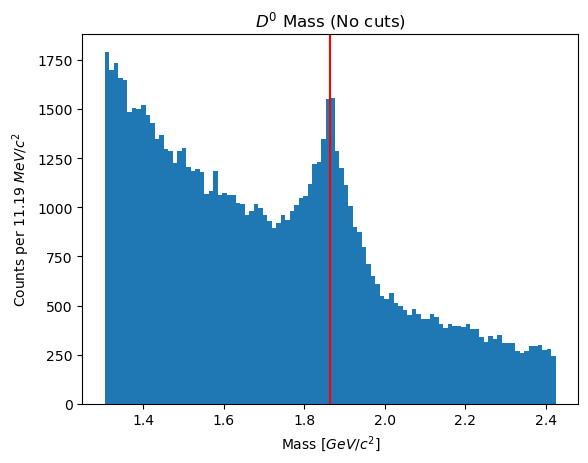

In [13]:
MIN_MASS, MAX_MASS = 0.7*m_d0, 1.3*m_d0
N_BINS = 100
#only_D0= final_results["Is_This_D0"] == True
plt.hist(final_results["inv_mass_candidate"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
plt.axvline(x=m_d0, color="red")
plt.xlabel("Mass [$GeV/c^2$]")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
plt.title("$D^0$ Mass (No cuts)")
#plt.savefig("D0_Mass_MC.png")
plt.show()

In [14]:
# etichetta con intervallo di pT
#final_result["interval"] = pd.cut(final_result['fMainMotherPt'], bins=Pt_intervals, labels=Pt_labels, right=True)

In [15]:
# divisione del dataframe per zone di pT----questa cosa non la usiamo per i fit ma magari viene utile piu' avanti
#final_result_pt_int = {label: group for label, group in df.groupby('interval')}

/tmp/ipykernel_38441/390819251.py:51: OptimizeWarning: Covariance of the parameters could not be estimated
  exp_fit_res = curve_fit( f = exponential_model, xdata = centers, ydata = counts, p0 = [ -10000, 7000, m_d0, 0.1/6., -0.2, m_d0, 200 ], maxfev=10000 )
/tmp/ipykernel_38441/390819251.py:9: RuntimeWarning: overflow encountered in exp
  return ( N * norm.pdf( x, loc = mu, scale = sig ) + pedestal + A*np.exp( ( x - off ) / tau ) )


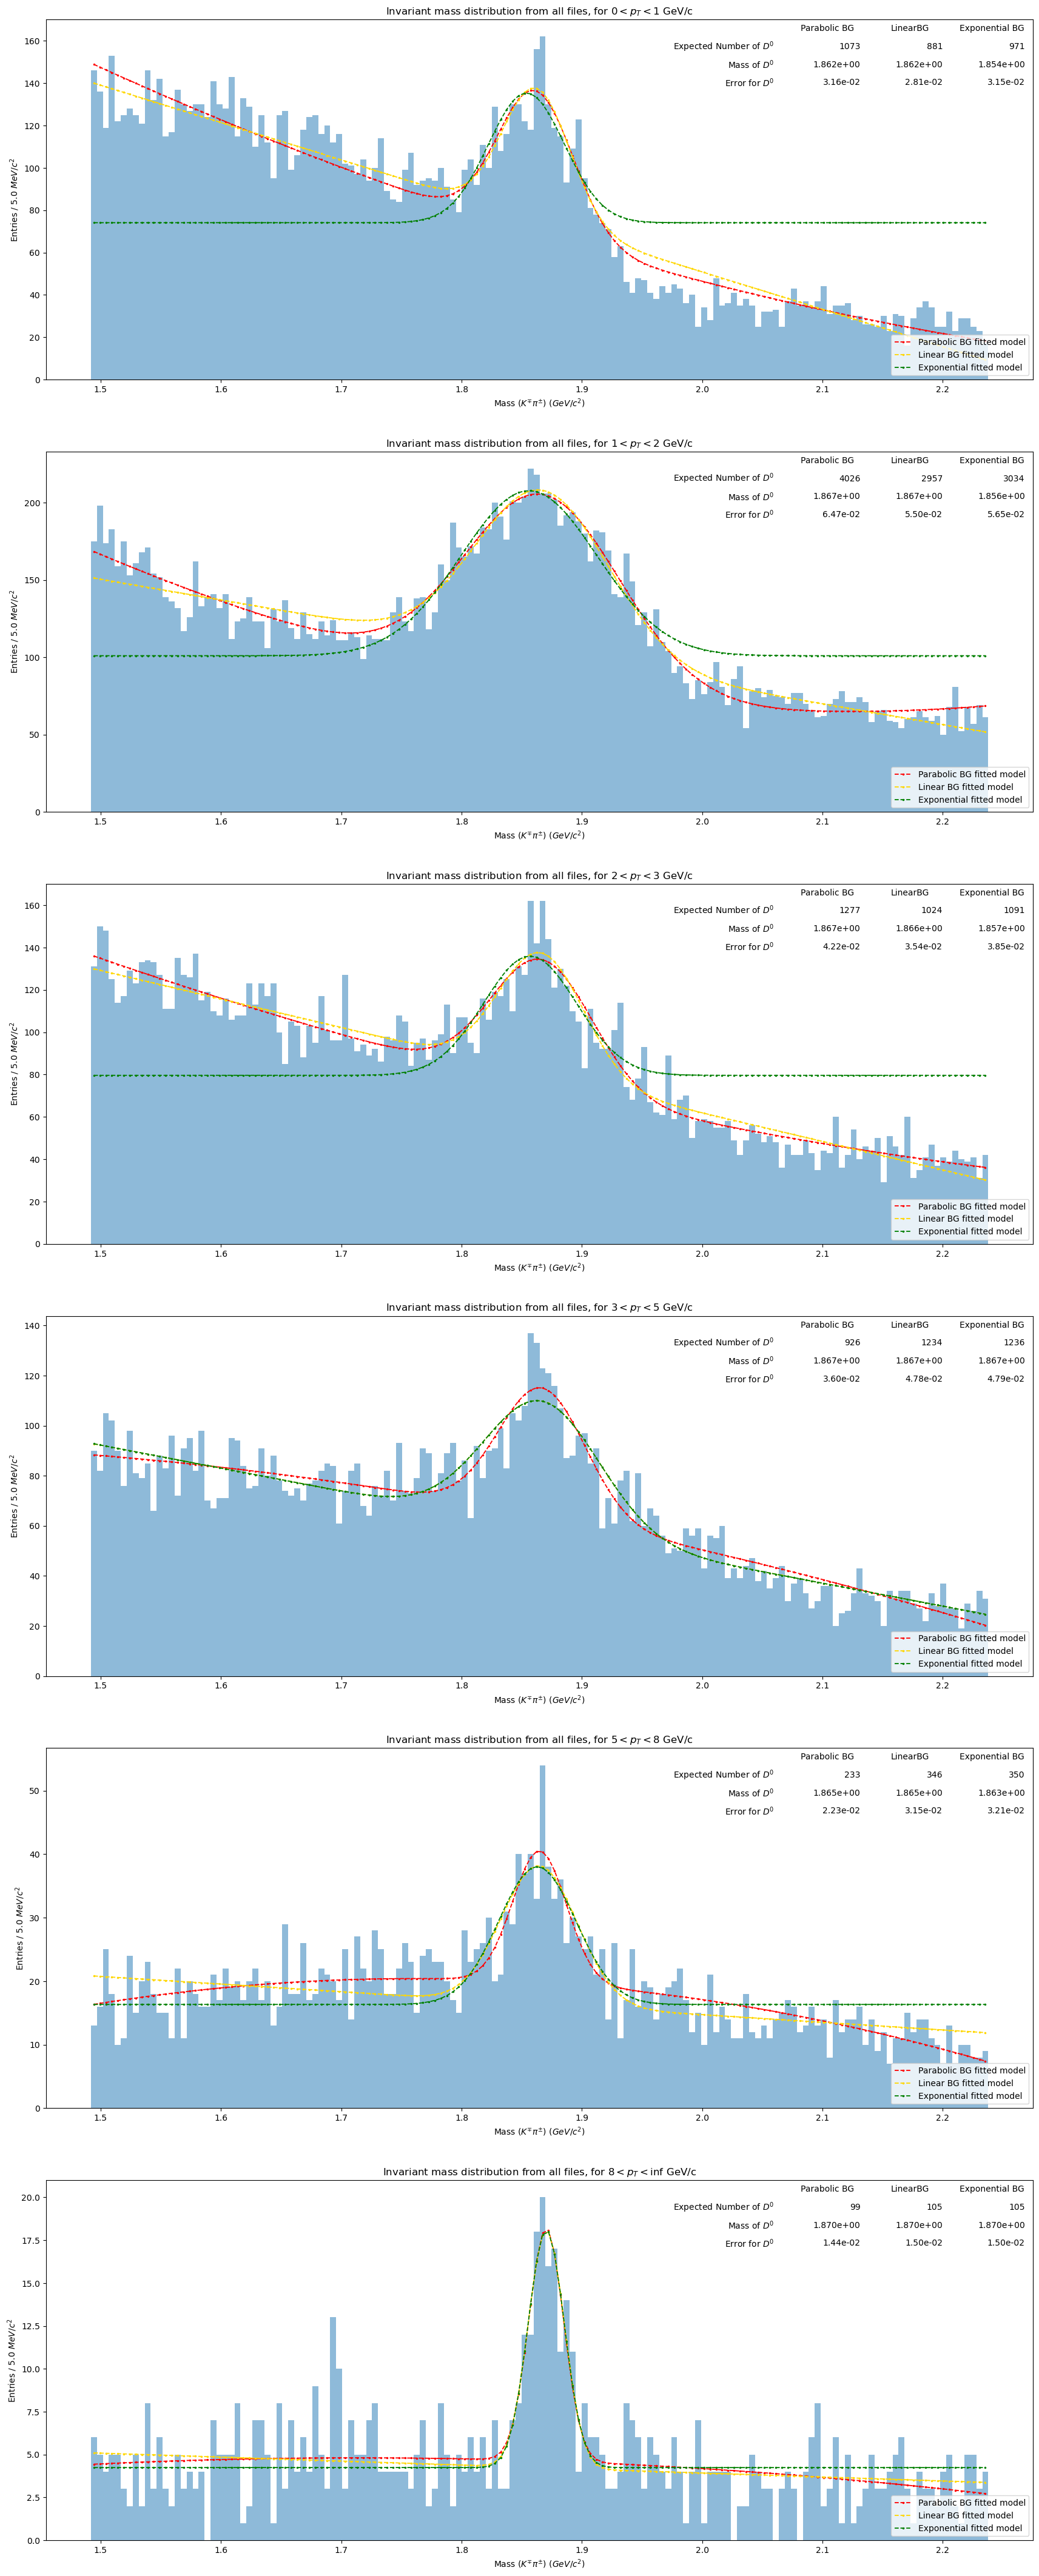

,Background,Pt_interval,Amplitude,Pedestal,Mu,Sigma,Slope,B,A,Tau,Offset,D0_counts
0,Linear,"[0, 1]",4.3929,403.5337,1.8622,0.0281,-176.3312,NaN,NaN,NaN,NaN,880.9755
1,Parabolic,"[0, 1]",5.3514,786.5078,1.8616,0.0316,NaN,-594.1740,112.0748,NaN,NaN,1073.1985
2,Exponential,"[0, 1]",4.8440,74.0995,1.8539,0.0315,NaN,NaN,NaN,-0.2259,-5733.3662,971.4494
3,Linear,"[1, 2]",14.7456,352.1556,1.8672,0.0550,-134.4156,NaN,NaN,NaN,NaN,2957.1776
4,Parabolic,"[1, 2]",20.0747,1256.1013,1.8674,0.0647,NaN,-1124.2115,265.2448,NaN,NaN,4025.9217
5,Exponential,"[1, 2]",15.1310,100.9754,1.8560,0.0565,NaN,NaN,NaN,-0.2180,-3399.3782,3034.4798
6,Linear,"[2, 3]",5.1085,330.9719,1.8663,0.0354,-134.5533,NaN,NaN,NaN,NaN,1024.4931
7,Parabolic,"[2, 3]",6.3678,619.6822,1.8669,0.0422,NaN,-450.0369,84.5427,NaN,NaN,1277.0463
8,Exponential,"[2, 3]",5.4414,79.6052,1.8569,0.0385,NaN,NaN,NaN,-0.2181,-746.5081,1091.2597
9,Linear,"[3, 5]",6.1542,230.0192,1.8666,0.0478,-91.8628,NaN,NaN,NaN,NaN,1234.2009


In [16]:
# fit per ogni intervallo di pT

# define the fit model
def parabolic_model( x, pedestal, N, mu, sig, B, A ) :
    return ( N * norm.pdf( x, loc = mu, scale = sig ) + pedestal + B*x + A*x**2 )
def linear_model( x, pedestal, N, mu, sig, rho ) :
    return ( N * norm.pdf( x, loc = mu, scale = sig )  + pedestal + x * rho )
def exponential_model( x, pedestal, N, mu, sig, tau, off, A ) :
    return ( N * norm.pdf( x, loc = mu, scale = sig ) + pedestal + A*np.exp( ( x - off ) / tau ) )

# variables and parameters
N_BINS = 150
m_d0 = 1.86484
MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0
STEP = (MAX_MASS-MIN_MASS)/N_BINS

N_recap = []
pedestal_recap = []
mu_recap = []
sigma_recap = []
par1_recap = []
par2_recap = []
interval_recap = []
BKG_type = []
slope = []
all_Bs = []
all_As = []
all_offsets = []
all_taus = []
D0_counts = []

pt_extremes = [[0, 1] , [1,2] , [2,3] , [3,5] , [5,8] , [8, np.inf]]
times = len(pt_extremes)

fig, axs = plt.subplots( nrows = times, ncols = 1, figsize = ( 21, 9 * times ) )

# perform the fit
for i in range( times ) :
    pt_lim = pt_extremes[ i ]
    ax = axs[ i ]
    mass = final_results[final_results["pt"].between(pt_lim[0], pt_lim[1])]["inv_mass_candidate"]
    
    counts, edges, _ = ax.hist(mass, bins=N_BINS, range=(MIN_MASS, MAX_MASS), align="mid", alpha=0.5)
    centers = ( edges[:-1] + edges[1:] ) / 2.
    
    # fitting the models
    parab_fit_res = curve_fit( f = parabolic_model, xdata = centers, ydata = counts, p0 = [ 12500, 7000, m_d0, 0.1/6., -0.1, 0.01 ] )
    parab_pars = parab_fit_res[0]
    lin_fit_res = curve_fit( f = linear_model, xdata = centers, ydata = counts, p0 = [ 20000, 7000, m_d0, 0.1/6., 50000 ] )
    lin_pars = lin_fit_res[0]
    exp_fit_res = curve_fit( f = exponential_model, xdata = centers, ydata = counts, p0 = [ -10000, 7000, m_d0, 0.1/6., -0.2, m_d0, 200 ], maxfev=10000 )
    exp_pars = exp_fit_res[0]
    # plotting the results
    ax.plot( centers, parabolic_model( centers, parab_pars[0], parab_pars[1], parab_pars[2], parab_pars[3], parab_pars[4], parab_pars[5] ),
        color='red', marker='o', linestyle='dashed', linewidth=1.3, markersize=1.5, label = 'Parabolic BG fitted model' )
    ax.plot( centers, linear_model( centers, lin_pars[0], lin_pars[1], lin_pars[2], lin_pars[3], lin_pars[4] ),
        color='gold', marker='o', linestyle='dashed', linewidth=1.3, markersize=1.5, label = 'Linear BG fitted model' )
    ax.plot( centers, exponential_model( centers, exp_pars[0], exp_pars[1], exp_pars[2], exp_pars[3], exp_pars[4], exp_pars[5],exp_pars[6] ),
        color='green', marker='o', linestyle='dashed', linewidth=1.3, markersize=1.5, label = 'Exponential fitted model' )

    m_parab = parab_pars[2]
    s_parab = parab_pars[3]
    K_parab = parab_pars[1]*( norm.cdf( m_parab + 3.*s_parab, loc = m_parab, scale = s_parab )
                          - norm.cdf( m_parab - 3.*s_parab, loc = m_parab, scale = s_parab ))/STEP
    m_lin = lin_pars[2]
    s_lin = lin_pars[3]
    K_lin = lin_pars[1]*( norm.cdf( m_lin + 3.*s_lin, loc = m_lin, scale = s_lin )
                          - norm.cdf( m_lin - 3.*s_lin, loc = m_lin, scale = s_lin ))/STEP
    m_exp = exp_pars[2]
    s_exp = exp_pars[3]
    K_exp = exp_pars[1]*( norm.cdf( m_exp + 3.*s_exp, loc = m_exp, scale = s_exp )
                          - norm.cdf( m_exp - 3.*s_exp, loc = m_exp, scale = s_exp ) )/STEP


    ax.table( 
        cellText = [[f"{K_parab:.0f}", f"{K_lin:.0f}", f"{K_exp:.0f}"],[ f"{m_parab:.3e}", f"{m_lin:.3e}", f"{m_exp:.3e}" ], [f"{s_parab:.2e}", f"{s_lin:.2e}", f"{s_exp:.2e}"] ],
        rowLabels = [ r'Expected Number of $D^0$', r'Mass of $D^0$', r'Error for $D^0$'],
        colLabels = [ 'Parabolic BG', 'LinearBG', 'Exponential BG' ],
        # cellColours = [ [ ( 'red', 0.1 ), ( 'blue', 0.1 ) ], [ ( 'red', 0.1 ), ( 'blue', 0.1 ) ], [ ( 'red', 0.1 ), ( 'blue', 0.1 ) ] ],
        # cellColours = [ [ 'red', 'blue' ], [ 'red', 'blue' ],[ 'red', 'blue' ] ],
        bbox = [ 0.75, 0.8, 0.25, 0.2 ],
        edges = 'open',
        rowLoc = 'right',
        )

        
    # ax.text( m_parab, hist.min() + 30 , r'Expected $K_S^0$: ' + f"{K_parab:.0f}", size = 25, c= 'red', horizontalalignment='center' )
    # ax.text( m_lin, hist.min() , r'Expected $K_S^0$: ' + f"{K_lin:.0f}", size = 25, c= 'blue', horizontalalignment='center' )
    # # ax.text( m_exp, exp_pars[0], r'Expected $K_S^0$: ' + f"{K_exp:.0f}", size = 25, c= 'blue' )
    
    
    ax.set_title( r"Invariant mass distribution from all files, for " + str(pt_lim[0]) + r"$ < p_{T} <$" + str(pt_lim[1]) + r" GeV/c" )
    # to reset into linear scale, default histo for the function
    ax.set_yscale( 'linear' )
    ax.set_xlabel( r'Mass ($K^{\mp}\pi^{\pm}$) $(GeV/c^2)$')
    ax.set_ylabel( r"Entries / "+f"{STEP*1000.:.1f}"+r" $MeV/c^2$")
    ax.legend( loc = 'lower right' )

    N_recap.append(lin_pars[1]); N_recap.append(parab_pars[1]); N_recap.append(exp_pars[1]);
    pedestal_recap.append(lin_pars[0]); pedestal_recap.append(parab_pars[0]); pedestal_recap.append(exp_pars[0]);
    mu_recap.append(lin_pars[2]); mu_recap.append(parab_pars[2]); mu_recap.append(exp_pars[2]);
    sigma_recap.append(lin_pars[3]); sigma_recap.append(parab_pars[3]); sigma_recap.append(exp_pars[3]);
    BKG_type.append("Linear"); BKG_type.append("Parabolic"); BKG_type.append("Exponential");
    slope.append(lin_pars[4]); slope.append(None); slope.append(None);
    all_Bs.append(None); all_Bs.append(parab_pars[4]); all_Bs.append(None);  
    all_As.append(None); all_As.append(parab_pars[5]); all_As.append(None);
    all_taus.append(None);  all_taus.append(None);  all_taus.append(exp_pars[4]);
    all_offsets.append(None); all_offsets.append(None); all_offsets.append(exp_pars[5]);
    D0_counts.append(K_lin); D0_counts.append(K_parab); D0_counts.append(K_exp); 
    
    #par1_recap.append()
    #par2_recap = []
    for tt in range (3):
        interval_recap.append(pt_lim)

pd.set_option("display.precision", 4)
recap = pd.DataFrame({
    "Background": BKG_type,
    "Pt_interval": interval_recap,
    "Amplitude": N_recap,
    "Pedestal": pedestal_recap,
    "Mu": mu_recap,
    "Sigma": sigma_recap,
    "Slope": slope,
    "B": all_Bs,
    "A": all_As,
    "Tau": all_taus,
    "Offset": all_offsets,
    "D0_counts": D0_counts
})
plt.show()

recap
    

In [17]:
n_reco_fit = sum(recap[recap["Background"]== "Parabolic"]["D0_counts"])
n_reco_fit

7633.787682085034

In [18]:
final_results.to_csv("MC_combinatorial_data.csv", index=True)

In [19]:
final_results

,Unnamed: 0,collision_index,dcaXY_product,inv_mass,anti_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,pdg_neg,MC_mother_pdg_pos,MC_mother_pdg_neg,MC_beauty_ancestor_pos,MC_beauty_ancestor_neg,MC_mother_origin_pos,MC_mother_origin_neg,N_final_states_pos,N_final_states_neg,inv_mass_candidate
1,1,0,-2.2673e-05,0.9541,0.9768,1.3511,-0.3870,0.0173,0.9877,0.8189,...,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.9768
31,31,2,-4.5794e-06,2.6463,2.8132,2.2473,0.5202,0.1019,0.9963,2.8202,...,-2212.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,2.6463
33,33,2,-4.2371e-06,0.9803,1.4142,3.2285,0.5838,0.0086,0.9557,2.8202,...,-2212.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,1.4142
41,41,2,-4.4375e-06,0.6579,0.8341,1.4506,0.1950,0.0751,1.0000,0.9658,...,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.8341
47,47,2,-1.1133e-05,1.1229,1.2884,1.7605,-0.4354,0.0070,0.9382,1.4073,...,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,1.2884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5618880,5618880,219043,-2.1136e-05,0.6998,0.7430,1.0794,-0.1514,2.9518,0.9997,0.6025,...,-321.0,0.0,0.0,0.0,0.0,218256.0,218256.0,0.0,0.0,0.7430
5618894,5618894,219043,-2.7640e-06,0.9739,0.7429,1.2329,0.3209,0.0164,0.9249,0.3249,...,-211.0,4122.0,0.0,0.0,0.0,2916996.0,218256.0,3.0,0.0,0.9739
5618915,5618915,219047,-7.5936e-05,1.0874,0.9789,0.8851,0.4638,0.0203,0.9957,0.4202,...,-211.0,0.0,0.0,0.0,0.0,218256.0,218256.0,0.0,0.0,1.0874
5619156,5619156,219048,-4.6464e-06,1.7430,1.5101,1.1881,-1.0698,0.0184,0.9205,0.3225,...,-211.0,0.0,0.0,0.0,0.0,218256.0,218256.0,0.0,0.0,1.7430


## Generated particles

In [20]:
# file by file...
file = uproot.open(base_path + "/" + which_file)
all_files = file.keys(filter_name = r"DF_*")
file_ID = list(set([code.split("/")[0] for code in all_files]))
# remove the directoryes code
file_ID = [s for s in file_ID if not s.endswith(";1")]

gen_particles = []
gen_D_0 = 0

for directory in file_ID:

    # merge the genparticles an mccollision dataframes on fIndexMcCollisions
    generated_part = file[directory + "/O2genparticles"].arrays(library="pd")
    mc_collision_df = file[directory + "/O2mccollision"].arrays(library="pd")
    generated_part = pd.merge(left=generated_part, right=mc_collision_df, how='inner', left_on='fIndexMcCollisions', right_index=True)
    
    # fPosZ cut
    generated_part = generated_part[generated_part["fPosZ"].abs() < 10]

    # Pseudorapidity cut
    generated_part = generated_part[generated_part["fMainMotherY"].abs() < acceptance]
    
    # Check on the fMainBeautyAncestor = 0
    generated_part = generated_part[generated_part["fMainBeautyAncestorPdgCode"] == 0]

    # Check the identity of the mother particle 
    generated_part = generated_part[generated_part["fPdgCode"].isin([421, -421])]

    # count the generated particles selected after the cuts file by file
    n_gen_D_0 = len(generated_part)
    #print("In this file there are", n_gen_D_0, "D_0 generated")

    # Update the total number of generated particles
    gen_D_0 += n_gen_D_0 

    gen_particles.append(generated_part)

In [21]:
gen_D_0

21656

In [22]:
total_eff = n_reco_fit/gen_D_0
print("Raw efficiency: ", total_eff)

Raw efficiency:  0.35250220179557784


In [54]:
gen_particles[0].columns

Index(['fPdgCode', 'fIndexMcCollisions', 'fMainBeautyAncestorPdgCode',
       'fMainMotherPt', 'fMainMotherY', 'fMaxEtaDaughter',
       'fMainBeautyAncestorPt', 'fMainBeautyAncestorY', 'fIndexBCs',
       'fGeneratorsID', 'fPosX', 'fPosY', 'fPosZ', 'fT', 'fWeight',
       'fImpactParameter', 'interval'],
      dtype='object')

In [23]:
gen_D0_Pt = []

for data_frame in gen_particles:
    data_frame["interval"] = pd.cut(data_frame['fMainMotherPt'], bins=Pt_intervals, labels=Pt_labels, right=True)
    r = data_frame.groupby("interval", observed=True).size()
    gen_D0_Pt.append(r)

tot_D0_Pt = reduce(lambda x, y: x.add(y, fill_value=0), gen_D0_Pt)


In [24]:
print(tot_D0_Pt,"\n")
print("tot:", sum(tot_D0_Pt))
max_Pt_list = [df["fMainMotherPt"].max() for df in gen_particles]
max_Pt = max(max_Pt_list)

# Check we are not loosing particles
if (sum(tot_D0_Pt) < gen_D_0): print("We are loosing paticles...enlarge the last interval up to", max_Pt)

interval
0-1     4558.0
1-2     6528.0
2-3     4441.0
3-5     4044.0
5-8     1525.0
8-41     559.0
dtype: float64 

tot: 21655.0
We are loosing paticles...enlarge the last interval up to 43.902244567871094


In [87]:
sum(recap[recap["Background"]=="Parabolic"]["D0_counts"])

7633.787682085034

In [26]:
numerator = np.array(recap[recap["Background"]=="Parabolic"]["D0_counts"])
denominator = np.array(tot_D0_Pt)
efficiency = numerator/denominator

In [27]:
efficiency


array([0.23545382, 0.61671595, 0.28755828, 0.22903979, 0.15263892,
       0.176404  ])

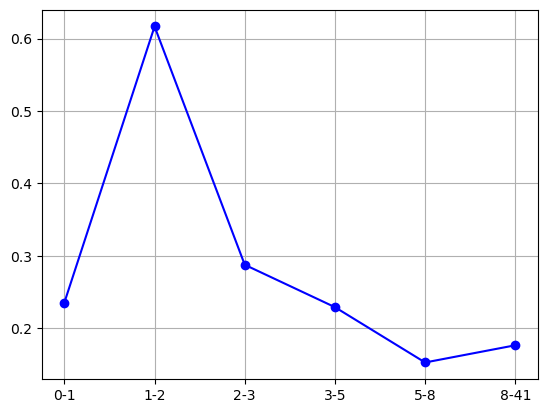

In [28]:
plt.plot(Pt_labels, efficiency, marker='o', linestyle='-', color='blue')
plt.grid()

In [48]:
numerator_1 = np.array(recap[recap["Background"]=="Parabolic"]["D0_counts"])

efficiency_cost = numerator/21566

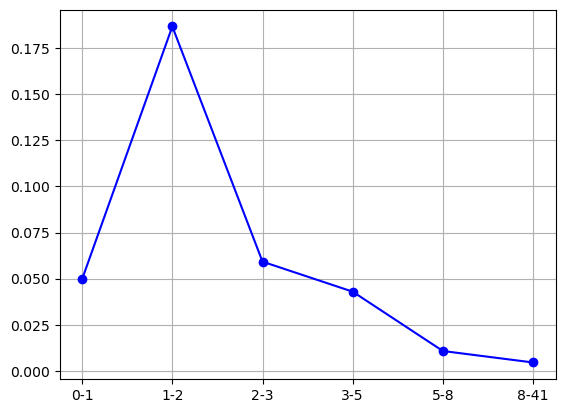

In [49]:
plt.plot(Pt_labels, efficiency_cost, marker='o', linestyle='-', color='blue')
plt.grid()

## MC check

In [29]:
MC_check = pd.read_csv("MC_combinatorial_data.csv")

In [30]:
MC_check.head(10)

,Unnamed: 0.1,Unnamed: 0,collision_index,dcaXY_product,inv_mass,anti_mass,pt,pz,decay_length,cos_pointing,...,pdg_neg,MC_mother_pdg_pos,MC_mother_pdg_neg,MC_beauty_ancestor_pos,MC_beauty_ancestor_neg,MC_mother_origin_pos,MC_mother_origin_neg,N_final_states_pos,N_final_states_neg,inv_mass_candidate
0,1,1,0,-2.2673e-05,0.9541,0.9768,1.3511,-0.3870,0.0173,0.9877,...,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.9768
1,31,31,2,-4.5794e-06,2.6463,2.8132,2.2473,0.5202,0.1019,0.9963,...,-2212.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,2.6463
2,33,33,2,-4.2371e-06,0.9803,1.4142,3.2285,0.5838,0.0086,0.9557,...,-2212.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,1.4142
3,41,41,2,-4.4375e-06,0.6579,0.8341,1.4506,0.1950,0.0751,1.0000,...,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.8341
4,47,47,2,-1.1133e-05,1.1229,1.2884,1.7605,-0.4354,0.0070,0.9382,...,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,1.2884
5,79,79,2,-4.3471e-05,0.8743,0.8732,0.9354,-0.4198,0.0202,0.9882,...,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.8743
6,96,96,2,-1.2860e-05,1.2296,0.9281,3.1752,2.2276,0.0315,0.9496,...,-211.0,421.0,0.0,0.0,0.0,8894.0,-1.0,2.0,0.0,1.2296
7,97,97,2,-5.6810e-06,1.3520,1.4301,0.4693,0.5134,0.0082,0.9599,...,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,1.4301
8,98,98,2,3.0847e-08,0.9632,1.0593,1.1926,0.2509,0.0290,0.9980,...,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,1.0593
9,115,115,3,2.4496e-06,1.6916,1.5008,3.1190,0.8221,0.0039,0.9284,...,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,1.6916


In [31]:
MC_check.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'collision_index', 'dcaXY_product',
       'inv_mass', 'anti_mass', 'pt', 'pz', 'decay_length', 'cos_pointing',
       'KA_pt', 'KA_TPCka', 'KA_TOFka', 'KA_fDcaXY', 'PI_pt', 'PI_TPCpi',
       'PI_TOFpi', 'PI_fDcaXY', 'KA_TPCpi', 'KA_TOFpi', 'PI_TPCka', 'PI_TOFka',
       'pdg_pos', 'pdg_neg', 'MC_mother_pdg_pos', 'MC_mother_pdg_neg',
       'MC_beauty_ancestor_pos', 'MC_beauty_ancestor_neg',
       'MC_mother_origin_pos', 'MC_mother_origin_neg', 'N_final_states_pos',
       'N_final_states_neg', 'inv_mass_candidate'],
      dtype='object')

In [32]:
len(MC_check)

252511

In [33]:
# Select the right particles (fPdgCode)
MC_check_pdg = MC_check[(MC_check["pdg_pos"].isin([211,321])) 
                    & (MC_check["pdg_neg"].isin([-211,-321])) 
                    & (abs(MC_check["pdg_pos"]) != abs(MC_check["pdg_neg"]))]


In [34]:
len(MC_check_pdg)

40553

In [35]:
# Select all the rows with fMainHfMotherPdgCode = 421 OR -421
MC_check_pdg_mother = MC_check_pdg[(MC_check_pdg["MC_mother_pdg_pos"].isin([421, -421]))
                                & (MC_check_pdg["MC_mother_pdg_pos"] == MC_check_pdg["MC_mother_pdg_neg"])]

In [36]:
len(MC_check_pdg_mother)

1004

In [37]:
# Select all the tracks that comes from a two particles decay
MC_check_pdg_mother_Nfinal =  MC_check_pdg_mother[(MC_check_pdg_mother["N_final_states_pos"]==2)
                                                    & (MC_check_pdg_mother["N_final_states_neg"]==2)]

In [38]:
len(MC_check_pdg_mother_Nfinal)

925

In [39]:
# Check on the fMainBeautyAncestor = 0
MC_check_pdg_mother_Nfinal_beauty = MC_check_pdg_mother_Nfinal[(MC_check_pdg_mother_Nfinal["MC_beauty_ancestor_pos"] == 0)
                                                                & (MC_check_pdg_mother_Nfinal["MC_beauty_ancestor_neg"] == 0)]

In [40]:
len(MC_check_pdg_mother_Nfinal_beauty)

631

In [41]:
# Check that the tracks come from the same mother
MC_check_final = MC_check_pdg_mother_Nfinal_beauty[
                    MC_check_pdg_mother_Nfinal_beauty["MC_mother_origin_pos"]==MC_check_pdg_mother_Nfinal_beauty["MC_mother_origin_neg"]]

In [42]:
len(MC_check_final)

618

In [43]:
#defined pT interval in which you can/want to “make the measurement”
MC_check_final["interval"] = pd.cut(MC_check_final["pt"], bins=Pt_intervals, labels=Pt_labels, right=True)
MC_count_D0 = MC_check_final.groupby("interval", observed=True).size()
MC_count_D0

/tmp/ipykernel_38441/1845595606.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MC_check_final["interval"] = pd.cut(MC_check_final["pt"], bins=Pt_intervals, labels=Pt_labels, right=True)


interval
0-1      13
1-2      78
2-3     114
3-5     244
5-8     110
8-41     59
dtype: int64

In [44]:
test = MC_check_final[MC_check_final["pt"].between(8, np.inf)]

print("D0:",len(test[test["MC_mother_pdg_pos"]==421]))
print("anti-D0:",len(test[test["MC_mother_pdg_pos"]==-421]))

D0: 25
anti-D0: 34


In [45]:
tot_D0_Pt

interval
0-1     4558.0
1-2     6528.0
2-3     4441.0
3-5     4044.0
5-8     1525.0
8-41     559.0
dtype: float64

In [46]:
MC_numerator = np.array(MC_count_D0)
MC_denominator = np.array(tot_D0_Pt)
MC_efficiency = MC_numerator/MC_denominator
MC_efficiency

array([0.00285213, 0.01194853, 0.02566989, 0.0603363 , 0.07213115,
       0.10554562])

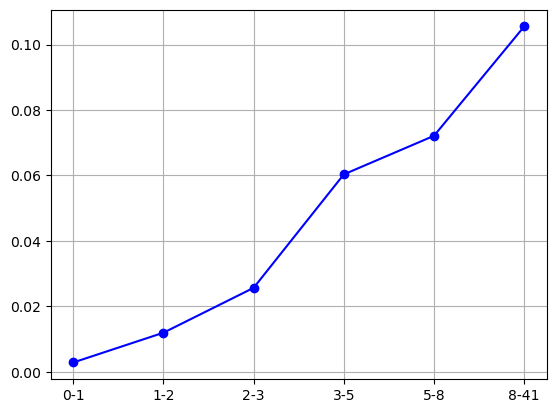

In [47]:
plt.plot(Pt_labels, MC_efficiency, marker='o', linestyle='-', color='blue')
plt.grid()

In [52]:
MC_numerator_1 = np.array(MC_count_D0)
MC_denominator_1 = sum(np.array(tot_D0_Pt))
MC_efficiency_1 = MC_numerator/MC_denominator_1
MC_efficiency

array([0.00060032, 0.00360194, 0.00526437, 0.01126761, 0.00507966,
       0.00272454])

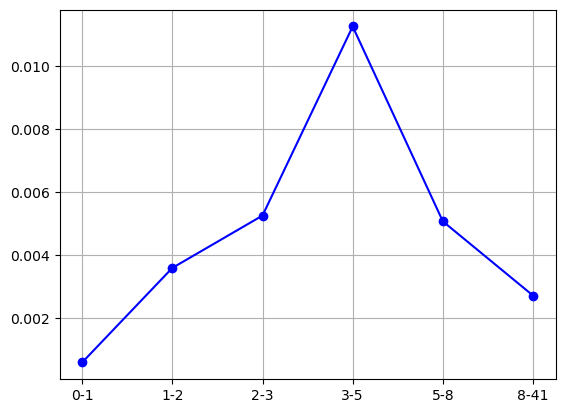

In [53]:
plt.plot(Pt_labels, MC_efficiency_1, marker='o', linestyle='-', color='blue')
plt.grid()

In [55]:
MC_check_1 = pd.read_csv("MC_combinatorial_data.csv")

In [76]:
par = recap[recap["Background"]=="Parabolic"][["Mu", "Sigma"]]
par

,Mu,Sigma
1,1.8616,0.0316
4,1.8674,0.0647
7,1.8669,0.0422
10,1.8669,0.0360
13,1.8649,0.0223
16,1.8704,0.0144


In [79]:
par.iloc[0]['Mu']

1.8616164710458207

In [69]:
pt_extremes = [[0, 1] , [1,2] , [2,3] , [3,5] , [5,8] , [8, np.inf]]


In [80]:
# pt mask
MC_check_pt = MC_check_1[MC_check_1["pt"].between(pt_extremes[0][0],pt_extremes[0][1])]


MC_check_mass = MC_check_pt[MC_check_pt["inv_mass_candidate"].between(par.iloc[0]['Mu']-3*par.iloc[0]['Sigma'],par.iloc[0]['Mu']+3*par.iloc[0]['Sigma'])]

In [81]:
MC_check_mass

,Unnamed: 0.1,Unnamed: 0,collision_index,dcaXY_product,inv_mass,anti_mass,pt,pz,decay_length,cos_pointing,...,pdg_neg,MC_mother_pdg_pos,MC_mother_pdg_neg,MC_beauty_ancestor_pos,MC_beauty_ancestor_neg,MC_mother_origin_pos,MC_mother_origin_neg,N_final_states_pos,N_final_states_neg,inv_mass_candidate
42,535,535,10,-2.0063e-05,1.8471,1.7858,0.5457,-0.0236,0.0756,0.9010,...,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,1.8471
122,2264,2264,82,2.6211e-05,1.6899,1.8066,0.6733,-0.5047,0.0394,0.9702,...,-321.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,1.8066
144,2789,2789,108,-7.7613e-06,1.8345,1.8009,0.4459,0.0306,0.0047,0.9175,...,-321.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,1.8345
145,2869,2869,111,1.2543e-05,1.9542,2.0312,0.7036,-0.2177,0.0306,0.9435,...,-211.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,1.9542
170,3245,3245,123,-1.0637e-06,1.9241,2.0122,0.9831,-0.0707,0.0082,0.9446,...,-321.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,1.9241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251987,5609489,5609489,218625,-4.6902e-06,1.8082,1.7539,0.4447,0.0170,0.1299,0.9183,...,-321.0,0.0,0.0,0.0,0.0,218256.0,218256.0,0.0,0.0,1.8082
252011,5609901,5609901,218640,-2.4301e-06,1.8639,1.7581,0.6870,0.5059,0.0090,0.9898,...,-211.0,0.0,0.0,0.0,0.0,218256.0,218256.0,0.0,0.0,1.8639
252110,5611556,5611556,218705,-1.3281e-06,1.7188,1.8273,0.7475,-0.3527,0.0411,0.9429,...,-211.0,0.0,0.0,0.0,0.0,218256.0,218256.0,0.0,0.0,1.8273
252297,5614818,5614818,218854,1.2108e-05,1.7249,1.8395,0.8178,0.2371,0.0790,0.9827,...,-211.0,0.0,0.0,0.0,0.0,218256.0,218256.0,0.0,0.0,1.8395


In [83]:
sum((MC_check_mass["MC_mother_pdg_neg"]==421))

54

In [85]:
len(MC_check_mass[(MC_check_mass["MC_mother_pdg_pos"].isin([421, -421]))
                                & (MC_check_mass["MC_mother_pdg_pos"] == MC_check_mass["MC_mother_pdg_neg"])])

28

In [86]:
MC_check_mass[(MC_check_mass["MC_mother_pdg_pos"].isin([421, -421]))
                                & (MC_check_mass["MC_mother_pdg_pos"] == MC_check_mass["MC_mother_pdg_neg"])]

,Unnamed: 0.1,Unnamed: 0,collision_index,dcaXY_product,inv_mass,anti_mass,pt,pz,decay_length,cos_pointing,...,pdg_neg,MC_mother_pdg_pos,MC_mother_pdg_neg,MC_beauty_ancestor_pos,MC_beauty_ancestor_neg,MC_mother_origin_pos,MC_mother_origin_neg,N_final_states_pos,N_final_states_neg,inv_mass_candidate
7410,137385,137385,5267,-1.4138e-04,1.8552,1.8601,0.9402,-0.1610,0.0167,0.9021,...,-321.0,421.0,421.0,521.0,521.0,919767.0,919767.0,2.0,2.0,1.8601
12926,238921,238921,9337,-4.3060e-05,1.8567,1.8390,0.7724,0.0792,0.0080,0.9844,...,-321.0,421.0,421.0,0.0,0.0,1018008.0,1018008.0,2.0,2.0,1.8567
31732,585411,585411,23170,-8.6472e-06,1.8748,1.8044,0.9861,0.7731,0.0053,0.9920,...,-321.0,421.0,421.0,-521.0,-521.0,2464116.0,2464116.0,2.0,2.0,1.8748
46479,854882,854882,34654,-5.2284e-05,1.9825,1.8633,0.8384,0.6524,0.0399,0.9800,...,-211.0,-421.0,-421.0,-5122.0,-5122.0,1933991.0,1933991.0,2.0,2.0,1.8633
56722,1040755,1040755,42454,-1.4152e-04,1.8779,1.9086,0.8312,0.0767,0.0134,0.9531,...,-321.0,421.0,421.0,521.0,521.0,1219131.0,1219131.0,2.0,2.0,1.8779
65170,1680544,1680544,61538,-1.3573e-04,1.8724,1.9219,0.9885,-0.3461,0.0162,0.9941,...,-321.0,421.0,421.0,-521.0,-521.0,1378002.0,1378002.0,2.0,2.0,1.8724
66629,1706226,1706226,62577,-1.5835e-05,1.8625,1.8181,0.4692,-0.3863,0.0058,0.9388,...,-321.0,421.0,421.0,0.0,0.0,1679262.0,1679262.0,2.0,2.0,1.8625
71128,1837708,1837708,67196,-4.3983e-06,1.9508,1.8559,0.9096,-0.3301,0.0053,0.9887,...,-211.0,-421.0,-421.0,-511.0,-511.0,1127754.0,1127754.0,2.0,2.0,1.8559
82931,2275375,2275375,82691,-2.6795e-04,1.8782,1.9803,0.9595,-0.5158,0.0408,0.9945,...,-321.0,421.0,421.0,0.0,0.0,2016460.0,2016460.0,2.0,2.0,1.8782
87189,2357351,2357351,86025,-1.7383e-05,1.8736,1.8106,0.9460,0.1446,0.0093,0.9512,...,-321.0,421.0,421.0,0.0,0.0,807885.0,807885.0,2.0,2.0,1.8736
